# 목표: 구별 가격 데이터 확인
- 구를 그룹화 -> 그룹별 평균 가격 구해서 구 ranking 매김

## 기본 데이터 로드

In [ ]:
import pandas as pd

df = pd.read_csv("C:\\Users\\jd091\\data\\train.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'
#df_b = pd.read_csv("C:\\Users\\jd091\\data\\test.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'

print(df.head())

C:\Users\jd091\AppData\Local\Temp\ipykernel_25388\2392849235.py:3: DtypeWarning: Columns (16,17,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Users\\jd091\\data\\train.csv", encoding='utf-8')  # 또는 'cp949', 'euc-kr'


             시군구     번지     본번   부번    아파트명  전용면적(㎡)    계약년월  계약일  층  건축년도  \
0  서울특별시 강남구 개포동  658-1  658.0  1.0  개포6차우성    79.97  201712    8  3  1987   
1  서울특별시 강남구 개포동  658-1  658.0  1.0  개포6차우성    79.97  201712   22  4  1987   
2  서울특별시 강남구 개포동  658-1  658.0  1.0  개포6차우성    54.98  201712   28  5  1987   
3  서울특별시 강남구 개포동  658-1  658.0  1.0  개포6차우성    79.97  201801    3  4  1987   
4  서울특별시 강남구 개포동  658-1  658.0  1.0  개포6차우성    79.97  201801    8  2  1987   

   ...    건축면적   주차대수 기타/의무/임대/임의=1/2/3/4                  단지승인일 사용허가여부  \
0  ...  4858.0  262.0                  임의  2022-11-17 13:00:29.0      Y   
1  ...  4858.0  262.0                  임의  2022-11-17 13:00:29.0      Y   
2  ...  4858.0  262.0                  임의  2022-11-17 13:00:29.0      Y   
3  ...  4858.0  262.0                  임의  2022-11-17 13:00:29.0      Y   
4  ...  4858.0  262.0                  임의  2022-11-17 13:00:29.0      Y   

  관리비 업로드        좌표X        좌표Y                  단지신청일  target  
0       N  127.

In [3]:
df[['시', '구', '동']] = df['시군구'].str.split(' ', expand=True)

cols = ['시', '구', '동'] + [col for col in df.columns if col not in ['시', '구', '동']]
df = df[cols]
df.head()

,시,구,동,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,...,건축면적,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target
0,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,79.97,201712,...,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,124000
1,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,79.97,201712,...,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,123500
2,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,54.98,201712,...,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,91500
3,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,79.97,201801,...,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,130000
4,서울특별시,강남구,개포동,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,79.97,201801,...,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,117000


## 데이터 전처리 

- 구, 동, target(가격) 데이터만 남김 

In [5]:
df=df[['구','동','target']]
df.head()

,구,동,target
0,강남구,개포동,124000
1,강남구,개포동,123500
2,강남구,개포동,91500
3,강남구,개포동,130000
4,강남구,개포동,117000


In [ ]:
#데이터를 구별로 그룹화 후 list
a=df.groupby('구')
a=list(a)

## 통계 데이터 구하기

In [9]:
#통계 데이터 구하기
# 구별 평균
gu_mean = df.groupby('구')['target'].mean()

# 구별 중앙값
gu_median = df.groupby('구')['target'].median()

# 구별 표준편차
gu_std = df.groupby('구')['target'].std()

# 구별 개수 (거래량)
gu_count = df.groupby('구')['target'].count()

# 구별 전체 통계 한번에 보기
gu_stats = df.groupby('구')['target'].agg(['mean', 'median', 'std', 'count']).reset_index()


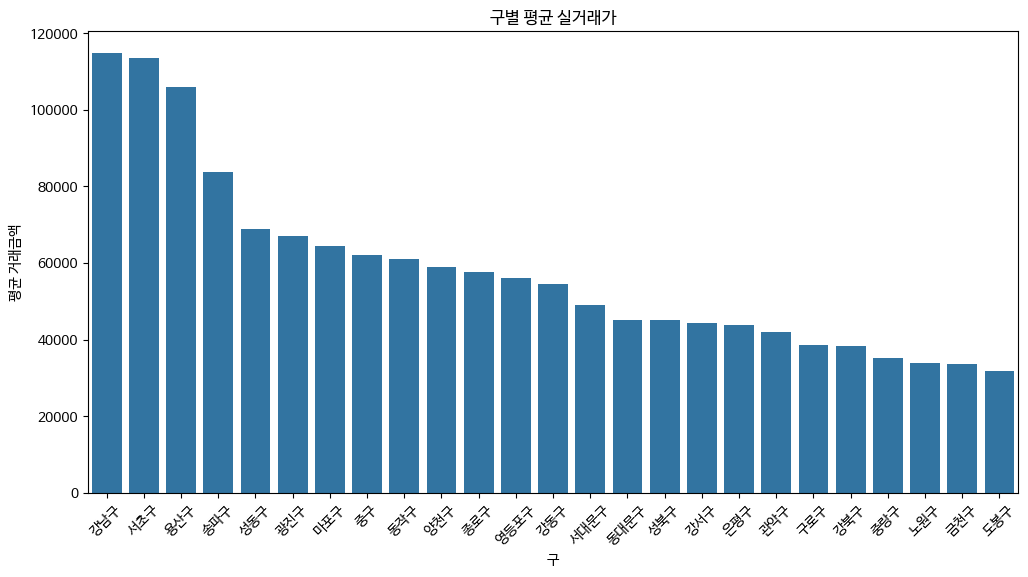

In [ ]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

#한글 폰트 설정 
fe = fm.FontEntry(
    fname=r'C:\\Windows\\Fonts\\NanumBarunGothic.ttf',
    name='NanumBarunGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumBarunGothic'  # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False        # 마이너스 깨짐 방지

# 평균 거래가 기준 막대그래프 그리기 
plt.figure(figsize=(12,6))
sns.barplot(data=gu_stats.sort_values('mean', ascending=False), x='구', y='mean')
plt.title('구별 평균 실거래가')
plt.xticks(rotation=45)
plt.ylabel('평균 거래금액')
plt.show()

In [18]:
#그래프를 참고해서 어디서 끊을 지 판단 
print("평균:", round(gu_mean.mean(),2))
print("중앙값:", round(gu_mean.median(),2))
print("표준편차:", round(gu_mean.std(),2))
print("최댓값:", round(gu_mean.max(),2))
print("최솟값:", round(gu_mean.min(),2))



평균: 57996.61
중앙값: 54402.87
표준편차: 23952.74
최댓값: 114847.46
최솟값: 31924.61


- 상위그룹 (고가지역): 평균 + 0.5σ 이상 (약 66,000 이상)

- 중간그룹 (중가지역): 평균 ± 0.5σ 사이 (약 48,000 ~ 66,000)

- 하위그룹 (저가지역): 평균 - 0.5σ 이하 (약 48,000 미만)

- 위 기준으로 삼은 이유
1. 표준편차는 데이터의 퍼짐 정도(분산)를 정량화  


표준편차는 데이터가 평균값에서 얼마나 떨어져 있는지를 나타내는 척도.


그래서 평균 ± 표준편차는 정규 분포 기반으로 중앙부 데이터의 범위를 설정하는데 자주 사용됨.

2. ±0.5σ는 데이터의 "상대적 중앙 영역"을 의미


정규분포일 경우, 전체 데이터의 약 **38%**가 평균 ±0.5σ 안에 포함됨.


따라서 이 구간은 가장 일반적인 중간 수준의 구들을 나타내는 데 적합.

3. ±1σ는 너무 넓고, ±0.25σ는 너무 좁음


±1σ를 쓰면 고가/저가 그룹이 너무 좁아져 분류가 희미해질 수 있음.


반대로 ±0.25σ를 쓰면 구간이 너무 좁아져 너무 민감하게 반응함.

±0.5σ는 중도적이며 직관적 기준으로 현실적인 구분이 가능함.

In [ ]:
mean = gu_stats['mean'].mean()
std = gu_stats['mean'].std()

gu_stats['price_group'] = pd.cut(gu_stats['mean'],
    bins=[0, mean - 0.5*std, mean + 0.5*std, float('inf')], #최소, 기준1, 기준2, 최대
    labels=['저가', '중가', '고가']
)

In [28]:
lista=list(gu_stats[gu_stats['price_group']=="저가"]['구'])
lista

['강북구', '강서구', '관악구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '성북구', '은평구', '중랑구']

In [29]:
listb=list(gu_stats[gu_stats['price_group']=="중가"]['구'])
listb

['강동구', '광진구', '동작구', '마포구', '서대문구', '성동구', '양천구', '영등포구', '종로구', '중구']

In [30]:
listc=list(gu_stats[gu_stats['price_group']=="고가"]['구'])
listc

['강남구', '서초구', '송파구', '용산구']